Algorithm Evaluation: Choosing the best model on basis of different performance metrics.

Importing all the necessary libraries


Read the dataset

In [1]:
# ignore non-harmful warnings
from warnings import filterwarnings
filterwarnings('ignore')

# To read the dataset
import pandas as pd

# To clean the data and preprocess it
# from sklearn.pipeline import make_pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler,OneHotEncoder
# from sklearn.compose import ColumnTransformer
from  data_clean_preprocess1 import clean_process_data


# Divide the data into training and testing
from sklearn.model_selection import train_test_split,cross_val_score

# Model buidling=> Decision Tree, Logistic Regression, Random Forest, Gradient Boost, XGBoost
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import  BernoulliNB



# Evaluation metrics
from sklearn.metrics import f1_score,ConfusionMatrixDisplay,classification_report,accuracy_score

In [2]:
path = r"C:\Users\admin\Downloads\datasets-train.csv"
df = pd.read_csv(path)
df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [3]:
print(f'Shape of Data:{df.shape}')
print(f'Columns present in dataset: {df.columns}')
print(f'Info of the dataset: {df.info()}')

Shape of Data:(136429, 14)
Columns present in dataset: Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-


Perform basic data quality checks

In [4]:
# Missing values
print(f'Missing Values ')
df.isna().sum()

Missing Values 


id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
## Duplicated rows
print(f'Duplicated rows')
df.duplicated().sum()

Duplicated rows


np.int64(0)

In [6]:
df = df.drop_duplicates()
print('Duplicated rows are dropped')

Duplicated rows are dropped


Separate X and Y features
Y: 'Machine failure'

In [7]:
df.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [8]:
df.columns=['id', 'Product ID', 'Type', 'Air temperature K',
       'Process temperature K', 'Rotational speed rpm', 'Torque Nm',
       'Tool wear min', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF']

In [9]:
df.head()

,id,Product ID,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


Temperature Difference = Process Temp – Air Temp

In [10]:
df['Temp_Difference'] = (df['Process temperature K'] - df['Air temperature K'])


In [11]:
df = df.drop(columns =['Process temperature K','Air temperature K'])

. Exploratory Data Analysis (EDA)
•	Visualize the distribution of features like temperature, speed, torque

•	Use histograms, boxplots, and pairplots

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

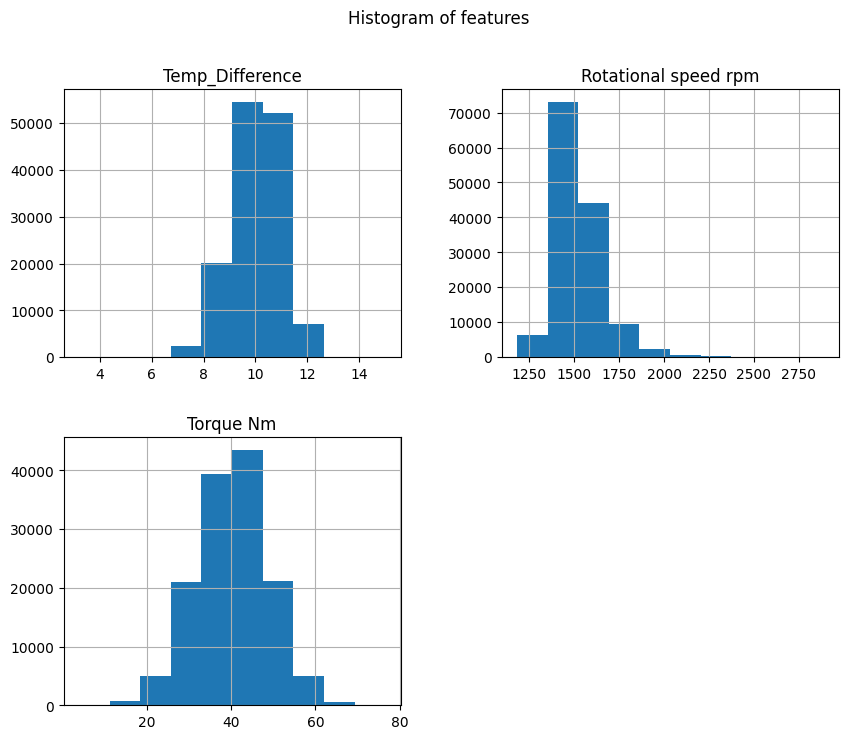

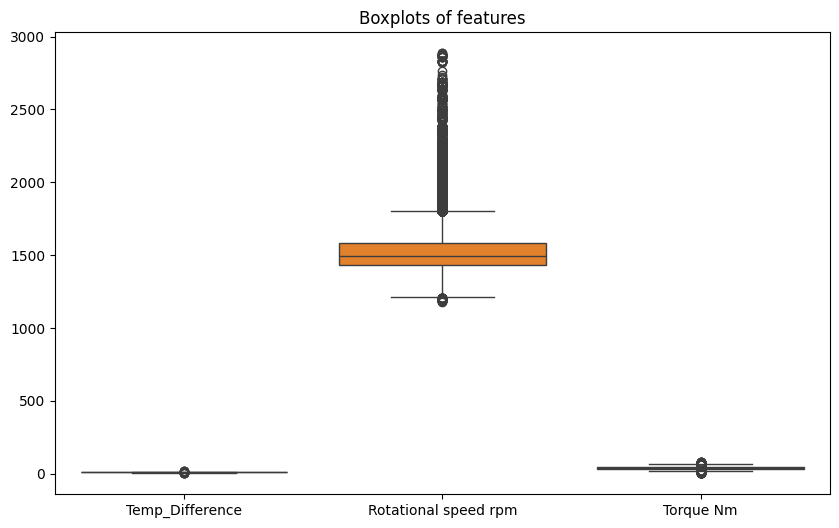

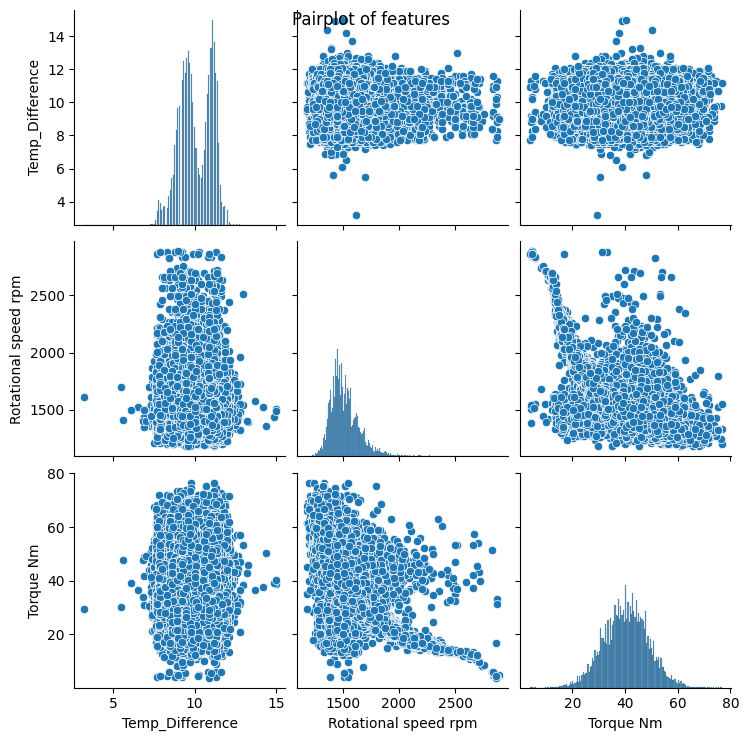

In [13]:
#histogram 
df[['Temp_Difference','Rotational speed rpm','Torque Nm']].hist (figsize =(10,8))
plt.suptitle('Histogram of features')
plt.show()

# Box plot 
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Temp_Difference','Rotational speed rpm','Torque Nm']])
plt.title('Boxplots of features')
plt.show()

#Pairplot
sns.pairplot(df[['Temp_Difference','Rotational speed rpm','Torque Nm']])
plt.suptitle('Pairplot of features')
plt.show()

There are  missing values but no  an duplicated rows in the data
Separate X and Y features

In [14]:
X = df.drop(columns=['id','Machine failure'])
Y = df[['Machine failure']]
print(X.head())
print('-------')
print(Y.head())

  Product ID Type  Rotational speed rpm  Torque Nm  Tool wear min  TWF  HDF  \
0     L50096    L                  1596       36.1            140    0    0   
1     M20343    M                  1759       29.1            200    0    0   
2     L49454    L                  1805       26.5             25    0    0   
3     L53355    L                  1524       44.3            197    0    0   
4     M24050    M                  1641       35.4             34    0    0   

   PWF  OSF  RNF  Temp_Difference  
0    0    0    0              9.0  
1    0    0    0              9.5  
2    0    0    0              9.2  
3    0    0    0              9.9  
4    0    0    0             11.0  
-------
   Machine failure
0                0
1                0
2                0
3                0
4                0


Data Preprocessing and Data cleaning

In [15]:
cat = list(X.columns[X.dtypes=='object'])
con = list(X.columns[X.dtypes!='object'])

In [16]:
from data_clean_preprocess1 import clean_process_data

In [17]:
pre,X_pre = clean_process_data(cat,con,X)
#X_pre.head()

In [18]:
pre

,transformers,"[('cat', ...), ('con', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [19]:
xtrain,xtest,ytrain,ytest = train_test_split(X_pre,Y,train_size=0.75,random_state=21)
print(f'xtrain.shape: {xtrain.shape}')
print(f'xtest.shape: {xtest.shape}')
print(f'ytrain.shape: {ytrain.shape}')
print(f'ytest.shape: {ytest.shape}')

xtrain.shape: (102321, 9988)
xtest.shape: (34108, 9988)
ytrain.shape: (102321, 1)
ytest.shape: (34108, 1)


DATA CHECK FOR IMBALANCE - DOWN SAMPLING WITH RANDOM UNDER SAMPLER

In [20]:
df['Machine failure'].value_counts()

Machine failure
0    134281
1      2148
Name: count, dtype: int64

In [21]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler()
x_us,y_us = rus.fit_resample(xtrain,ytrain)


In [22]:
x_us.head()

,cat__Product ID_H29424,cat__Product ID_H29425,cat__Product ID_H29432,cat__Product ID_H29434,cat__Product ID_H29441,cat__Product ID_H29452,cat__Product ID_H29457,cat__Product ID_H29462,cat__Product ID_H29466,cat__Product ID_H29481,...,cat__Type_M,con__Rotational speed rpm,con__Torque Nm,con__Tool wear min,con__TWF,con__HDF,con__PWF,con__OSF,con__RNF,con__Temp_Difference
79168,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,-1.025912,0.688217,-0.616103,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568,0.631218
119520,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.033653,-0.146861,1.947807,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568,-2.313153
22995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.096090,0.511792,-1.632287,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568,1.748048
60997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.585260,-1.934634,1.541334,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568,-1.196323
7302,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.091316,-0.029245,-1.632287,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568,1.138868


Algorithm Evaluation

In [23]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score

In [24]:
models =[
    LogisticRegression(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    XGBClassifier(),
    BernoulliNB()
]

In [25]:
def evaluate_model_performance(model,x_us,y_us,xtest,ytest):
    
    # Fit the model
    model.fit(x_us,y_us)

    # Predict the outputs-Machine Failiure
    ypred_train = model.predict(x_us)
    ypred_test = model.predict(xtest)

    # Evaluation on basis of metrics: f1-score
    f1_train = f1_score(y_us,ypred_train)
    f1_test = f1_score(ytest,ypred_test)

    # Evaluate through cross validation also
    scores = cross_val_score(model,x_us,y_us,cv=4,scoring='f1_macro')
    f1_cv = scores.mean()
   
    # Accuray Score on train dataset
    accuracy_train = accuracy_score(y_us,ypred_train)
    print('accuracy_score on train dataset :',accuracy_train)

    # Accuracy Score on test dataset
    accuracy_test = accuracy_score(ytest,ypred_test ) #(x_us,ypred_test)
    print('accuracy_score on test dataset : ',accuracy_test)
    
        

    # Returns all the above results for the model
    results = {
        'Name':type(model).__name__,
        'f1-score:training':f1_train,
        'f1-score:testing':f1_test,
        'f1-cv':f1_cv,
        'accuracy_score :training': accuracy_train,
        'accuracy_score :testing ':accuracy_test 
        }
    return results

In [26]:
def evaluate_model(models,x_us,y_us,xtest,ytest):
    res = []
    for m in models:
        r = evaluate_model_performance(m,x_us,y_us,xtest,ytest)
        # combine all the results of each model provided as input to above method into a res list
        res.append(r)
        
        
    # Convert these results into a dataframe and display
    results_df = pd.DataFrame(res)
    return results_df

In [27]:
score_results_df = evaluate_model (models,x_us,y_us,xtest,ytest)


accuracy_score on train dataset : 0.9210199004975125
accuracy_score on test dataset :  0.9873929869825261
accuracy_score on train dataset : 1.0
accuracy_score on test dataset :  0.9289316289433563
accuracy_score on train dataset : 1.0
accuracy_score on test dataset :  0.9464934912630468
accuracy_score on train dataset : 0.9856965174129353
accuracy_score on test dataset :  0.9344728509440601
accuracy_score on train dataset : 0.9446517412935324
accuracy_score on test dataset :  0.8781810718892928


In [28]:
score_results_df


,Name,f1-score:training,f1-score:testing,f1-cv,accuracy_score :training,accuracy_score :testing
0,LogisticRegression,0.914478,0.670245,0.902170,0.921020,0.987393
1,DecisionTreeClassifier,1.000000,0.284956,0.902295,1.000000,0.928932
2,RandomForestClassifier,1.000000,0.349376,0.923443,1.000000,0.946493
3,XGBClassifier,0.985489,0.299153,0.912245,0.985697,0.934473
4,BernoulliNB,0.942802,0.182891,0.861106,0.944652,0.878181


ROC- AUC -plot ROC and AUC GRAPHS FOR EACH MODEL

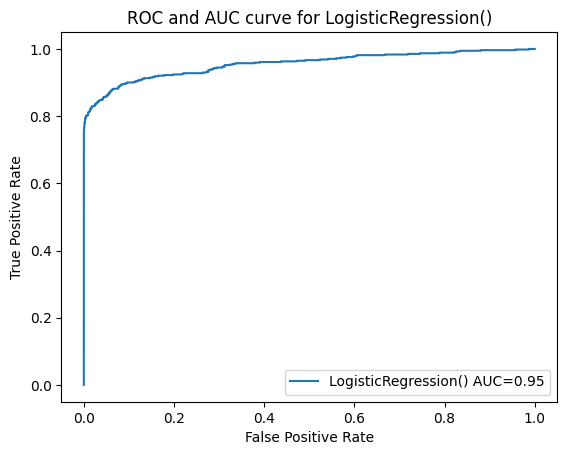

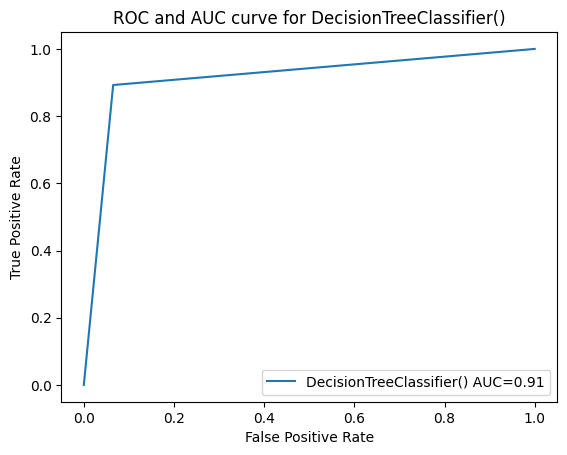

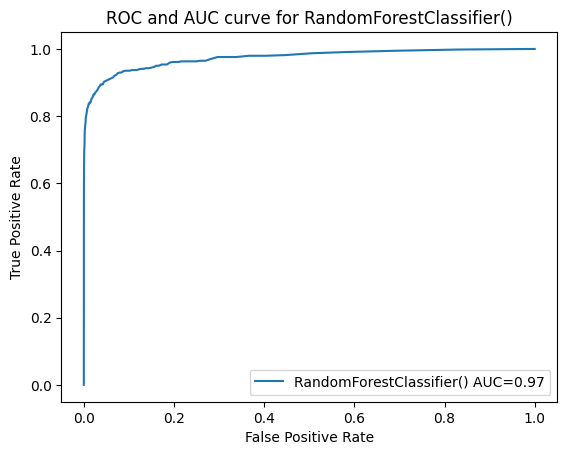

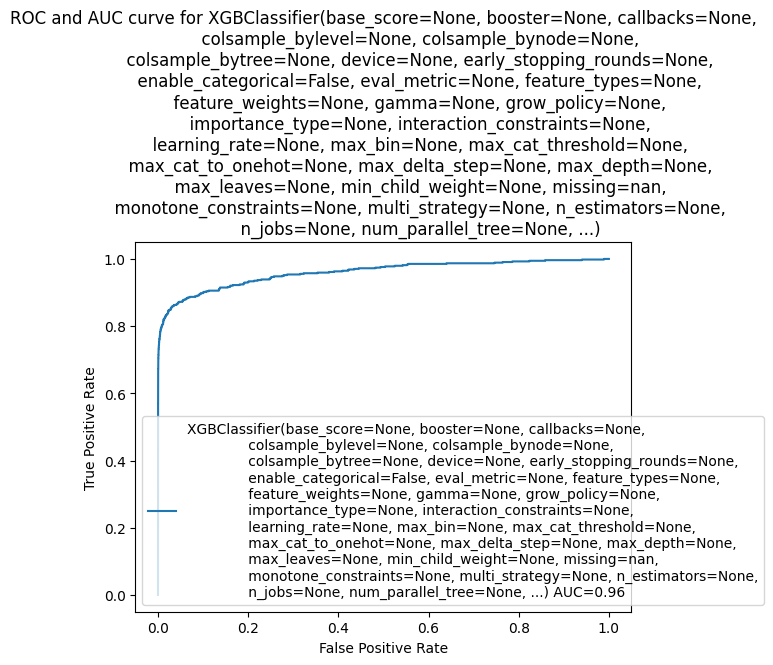

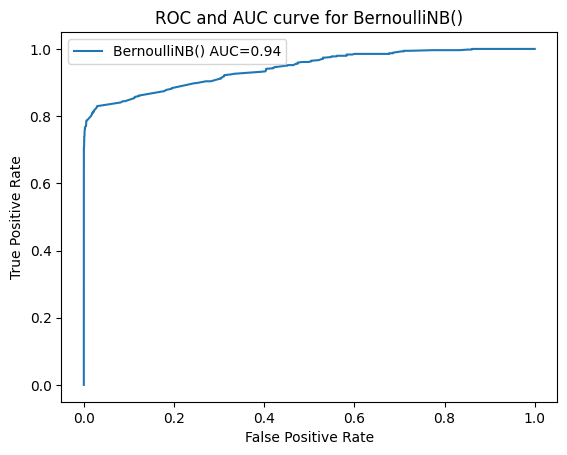

In [29]:
from sklearn.metrics import roc_curve,auc
import matplotlib.pyplot as plt
auc_scores =[ ]
for model in models:
    model.fit(x_us,y_us)
    y_pred_proba =model.predict_proba(xtest)[:,1] #get probability for the positive class
    fpr,tpr,thresholds = roc_curve(ytest,y_pred_proba )
    roc_auc_score = auc(fpr,tpr) #Main auc score for each model
    auc_scores.append(roc_auc_score)
    plt.plot (fpr,tpr,label=f'{model} AUC={roc_auc_score:.2f}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC and AUC curve for {model}')
    plt.legend()
    plt.show()

ADDITION OF AUC SCORES COLUMN IN dataframe of results (score_results_df)

In [30]:
score_results_df['Auc scores']= auc_scores

In [31]:
score_results_df


,Name,f1-score:training,f1-score:testing,f1-cv,accuracy_score :training,accuracy_score :testing,Auc scores
0,LogisticRegression,0.914478,0.670245,0.902170,0.921020,0.987393,0.954861
1,DecisionTreeClassifier,1.000000,0.284956,0.902295,1.000000,0.928932,0.913765
2,RandomForestClassifier,1.000000,0.349376,0.923443,1.000000,0.946493,0.973756
3,XGBClassifier,0.985489,0.299153,0.912245,0.985697,0.934473,0.959494
4,BernoulliNB,0.942802,0.182891,0.861106,0.944652,0.878181,0.942238


Finalising RandomForestClassifier on basis of highest AUC SCORES

In [32]:
from sklearn.model_selection import RandomizedSearchCV


hyperparameter tuning by considering RandomizedSearchCV

In [33]:
params = {
    'n_estimators':[5,6,8,7,10,35,50,55,75,100,150,200,200,300,400],
    'max_depth':[3,5,6,8,7,9,11],
    'min_samples_split':[1,2,3,4,5,6,7,8,9],
    'min_samples_leaf':[1,2,3,4,5,6,7,8,9],
    'criterion':['gini','entropy']
}

In [34]:
base_model = RandomForestClassifier()
rscv = RandomizedSearchCV (estimator=base_model,param_distributions = params, cv=5, scoring='roc_auc')
rscv.fit(x_us,y_us)

,estimator,RandomForestClassifier()
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [1, 2, ...], ...}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [35]:
rscv.best_params_

{'n_estimators': 200,
 'min_samples_split': 6,
 'min_samples_leaf': 1,
 'max_depth': 7,
 'criterion': 'gini'}

In [36]:
rscv.best_score_

np.float64(0.9439233738121858)

In [37]:
best_rfc = rscv.best_estimator_

In [38]:

best_rfc.score(x_us,y_us)   

0.8644278606965174

In [39]:
best_rfc.score(xtest,ytest)


0.9295180016418435

In [40]:
final_model = best_rfc
final_model.fit(x_us,y_us)

,n_estimators,200
,criterion,'gini'
,max_depth,7
,min_samples_split,6
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
final_model.score(x_us,y_us)

0.8830845771144279

In [42]:
final_model.score(xtest,ytest)

0.9520640318986748

Model Evaluation using confusion matrix, classification report, ROC-AUC curve

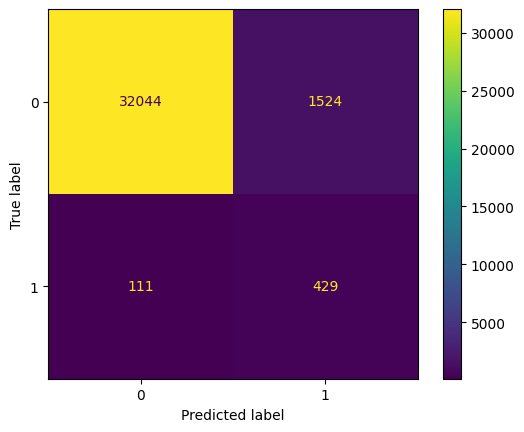

In [43]:
ConfusionMatrixDisplay.from_estimator(final_model,xtest,ytest)

In [44]:

print(classification_report(ytest,final_model.predict(xtest)))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     33568
           1       0.22      0.79      0.34       540

    accuracy                           0.95     34108
   macro avg       0.61      0.87      0.66     34108
weighted avg       0.98      0.95      0.97     34108




Using this model for final predictions

In [45]:
import pandas as pd
path2 = r'C:\Users\admin\Downloads\datasets-test.csv'
xnew = pd.read_csv(path2)
xnew.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0


In [46]:
xnew.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [47]:
xnew.columns = ['id', 'Product ID', 'Type', 'Air temperature K',
       'Process temperature K', 'Rotational speed rpm', 'Torque Nm',
       'Tool wear min', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

In [48]:

xnew_pre = pre.transform(xnew)

ValueError: columns are missing: {'Temp_Difference'}

In [ ]:

xnew_pre.head()

,cat__Product ID_H29424,cat__Product ID_H29425,cat__Product ID_H29432,cat__Product ID_H29434,cat__Product ID_H29441,cat__Product ID_H29452,cat__Product ID_H29457,cat__Product ID_H29462,cat__Product ID_H29466,cat__Product ID_H29481,...,con__Air temperature K,con__Process temperature K,con__Rotational speed rpm,con__Torque Nm,con__Tool wear min,con__TWF,con__HDF,con__PWF,con__OSF,con__RNF
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.308759,1.125444,-0.153753,-0.276240,-0.694271,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.986567,0.764477,1.388744,-1.358313,-1.366516,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.771772,0.331317,0.033653,-0.311525,-0.131461,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.127386,-0.246230,-0.297912,0.852880,-1.554119,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.899446,1.702992,-0.038426,0.111895,0.149943,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568


In [ ]:
Machine_Failiure_predicted = final_model.predict(xnew_pre)
Machine_Failiure_predicted[0:5]

array([0, 0, 0, 0, 0])

In [ ]:
xnew['Machine failiure Predicted'] = Machine_Failiure_predicted
xnew.to_csv('Machine Failiure Results.csv',index=False)

In [ ]:
xnew['Machine failiure Predicted'].unique()

array([0, 1])